In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
from IPython.display import Image, display

class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    message: str

def greeting_node(state: AgentState) -> AgentState:
    """Node responsible for generating a greeting message based on the state name"""
    state['message'] = f"{state['name']}, welcome to the system!"
    return state
    
def age_node(state: AgentState) -> AgentState:
    """Node responsible for adding age information to the message"""
    state['message'] = f"{state['message']} You are {state['age']} years old!"
    return state

def skills_node(state: AgentState) -> AgentState:
    """Node responsible for adding skills information to the message"""
    skills = ", ".join(state['skills'])
    
    state['message'] = f"{state['message']} You have sills in: {skills}"
    return state

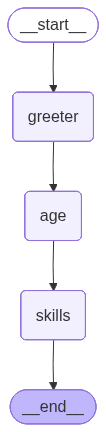

{'name': 'Aurelio',
 'age': 27,
 'skills': ['Python', 'Kotlin', 'Golang'],
 'message': 'Aurelio, welcome to the system! You are 27 years old! You have sills in: Python, Kotlin, Golang'}

In [2]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.add_node("age", age_node)
graph.add_node("skills", skills_node)

graph.set_entry_point("greeter")
graph.add_edge("greeter", "age")
graph.add_edge("age", "skills")
graph.set_finish_point("skills")

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

result = app.invoke({'name': 'Aurelio', 'age': 27, 'skills': ['Python', 'Kotlin', 'Golang']})
result